In [2]:
import pandas as pd
import seaborn as sns
import numpy as np


In [3]:
df=pd.read_csv('banking_transactions.csv')
df

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1009996,3552.90,1,36.6,21,0.16,1315,21,12,17919.66,117,14829,36,75.4,Mobile App,Password Only,0,0,1,False
9996,1009997,21559.69,11,14.4,28,0.26,4644,22,11,8477.85,15,10795,63,10.8,POS Terminal,Two-Factor Authentication,0,1,1,False
9997,1009998,4181.33,1,84.0,50,0.23,262,3,3,272564.27,60,3840,91,93.3,Mobile App,Biometric,0,1,1,False
9998,1009999,21443.71,3,33.8,44,0.01,255,4,14,142791.28,116,10110,42,87.1,Mobile App,OTP,1,1,1,False


In [4]:
df.head()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [6]:
df.isnull().sum()

transaction_id                    0
transaction_amount                0
login_attempts                    0
device_risk_score                 0
transfer_frequency                0
anomaly_score                     0
account_age_days                  0
transaction_time_hour             0
failed_transactions_last_30d      0
avg_monthly_balance               0
daily_transaction_count           0
geo_distance_km                   0
session_duration_minutes          0
transaction_velocity_score        0
payment_channel                   0
authentication_type               0
card_present_flag                 0
international_transaction_flag    0
suspicious_ip_flag                0
fraud_flag                        0
dtype: int64

In [12]:
df.columns

Index(['transaction_id', 'transaction_amount', 'login_attempts',
       'device_risk_score', 'transfer_frequency', 'anomaly_score',
       'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance',
       'daily_transaction_count', 'geo_distance_km',
       'session_duration_minutes', 'transaction_velocity_score',
       'payment_channel', 'authentication_type', 'card_present_flag',
       'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag'],
      dtype='object')

In [5]:
df.sample(5)

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
5563,1005564,4755.97,12,22.7,76,0.70,2633,20,18,385930.76,114,14169,69,97.1,Web Banking,OTP,1,1,1,False
9298,1009299,16015.27,2,43.0,29,0.01,2393,17,16,299517.25,40,10959,11,100.0,Web Banking,Biometric,0,1,1,False
6025,1006026,24768.00,11,47.9,20,0.21,3522,20,12,402378.94,104,8224,59,30.8,ATM,OTP,1,0,1,False
2955,1002956,17865.84,8,55.1,74,0.48,4800,14,16,131947.48,22,8367,32,25.4,ATM,OTP,1,0,1,False
9917,1009918,3529.40,5,0.0,40,0.81,3756,3,18,127439.04,32,4512,68,60.3,Mobile App,Two-Factor Authentication,1,1,0,True


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [9]:
df.describe()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.005000e+06,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500
std,2.886896e+03,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025
min,1.000001e+06,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002501e+06,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000
50%,1.005000e+06,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000
75%,1.007500e+06,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000
max,1.010000e+06,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000


In [13]:
import matplotlib.pyplot as plt

##Categorical data

In [ ]:
df['authentication_type'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

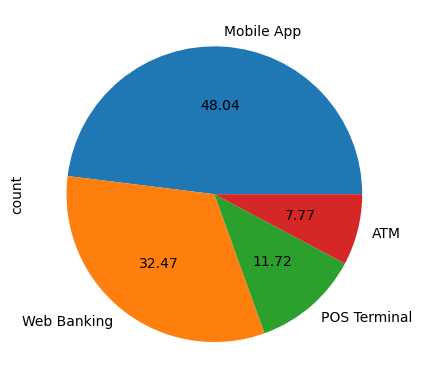

In [23]:
df['payment_channel'].value_counts().plot(kind='pie',autopct='%.2f')

([0, 1, 2, 3],
 [Text(0, 0, 'OTP'),
  Text(1, 0, 'Biometric'),
  Text(2, 0, 'Two-Factor Authentication'),
  Text(3, 0, 'Password Only')])

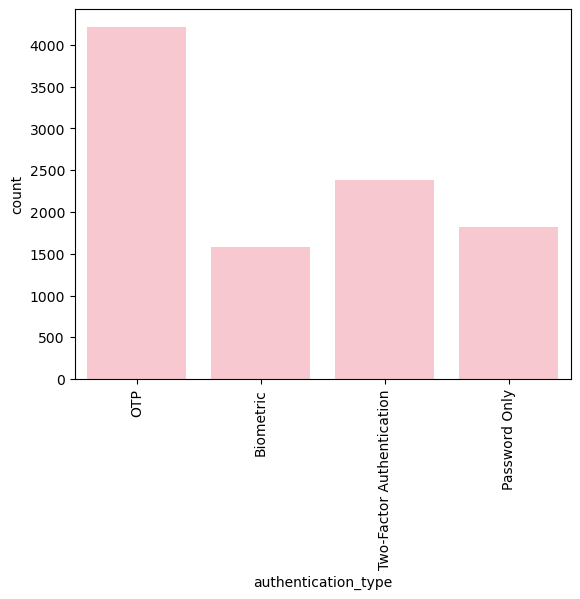

In [36]:
sns.countplot(x='authentication_type',data=df,color='pink')
plt.xticks(rotation=90)

<Axes: xlabel='payment_channel', ylabel='count'>

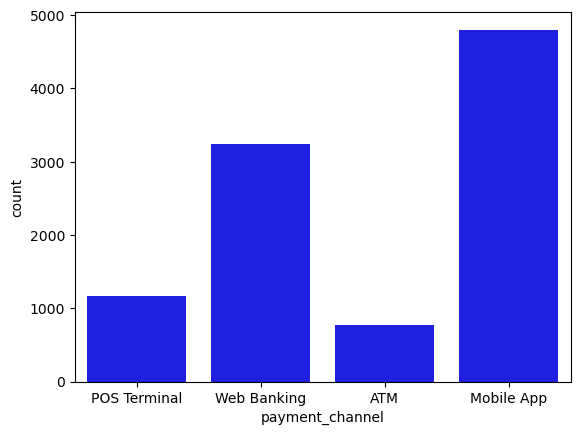

In [39]:
sns.countplot(x='payment_channel',data=df,color='blue')

#numerical data

<Axes: xlabel='anomaly_score', ylabel='Count'>

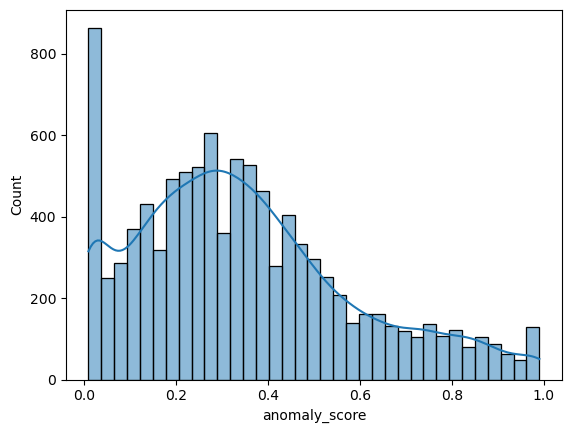

In [45]:
sns.histplot(df['anomaly_score'],kde=True)

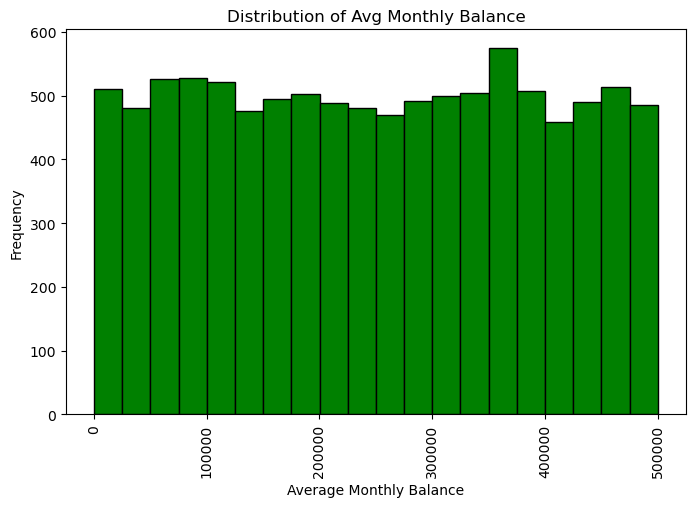

In [53]:
plt.figure(figsize=(8,5))
plt.hist(df['avg_monthly_balance'], bins=20, color='green', edgecolor='black')
plt.xlabel("Average Monthly Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Monthly Balance")
plt.xticks(rotation=90)
plt.show()

<Axes: ylabel='transaction_time_hour'>

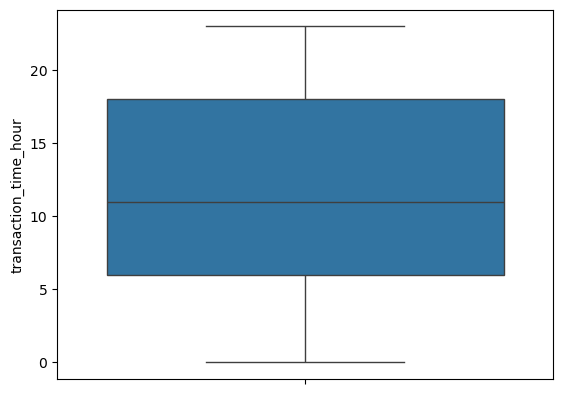

In [55]:
sns.boxplot(df['transaction_time_hour'])

In [56]:
df['device_risk_score'].min()


0.0

In [57]:
df['device_risk_score'].max()

100.0

In [58]:
df['transaction_time_hour'].min()

0

In [59]:
df['transaction_time_hour'].max()

23